In [2]:
import numpy as np
import os
import netCDF4 as nc  
import matplotlib.pyplot as plt
import sys
import importlib
import tcripser as tcr

In [3]:
# Get the path of the notebook file
notebook_path = os.getcwd()

# Directory containing the notebook file
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [4]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import cubical_pers_and_filt_visual, globe_visualization

importlib.reload(cubical_pers_and_filt_visual)
importlib.reload(globe_visualization)

<module 'globe_visualization' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/globe_visualization.py'>

# Loading the data

In [5]:
dSet_SL = nc.Dataset(notebook_directory+"/data/raw/slp.daily.nc")
# Extract variables from the dataset
# This example assumes there are time, lat, lon, and a variable 'hgt'
time = dSet_SL.variables['time'][:]
lat = dSet_SL.variables['lat'][:]
lon = dSet_SL.variables['lon'][:]
slp = dSet_SL.variables['slp'][:]

In [6]:
lat_cut = [[0,90]]
lon_cut = [[0,360]]

In [7]:
# Function to check if a value is within any of the specified ranges
def is_in_ranges(value, ranges):
    for r in ranges:
        if r[0] <= value <= r[1]:
            return True
    return False

In [8]:
def give_index(list,list_cut):
    indices = []
    for i in range(len(list.data)):
        if is_in_ranges(list.data[i],list_cut):
            indices.append(i)
    return indices

lon_index = give_index(lon,lon_cut)
lat_index = give_index(lat,lat_cut)

In [9]:
slp_new = slp[:,lat_index,:][:,:,lon_index]

In [10]:
slp.data.shape

(27919, 73, 144)

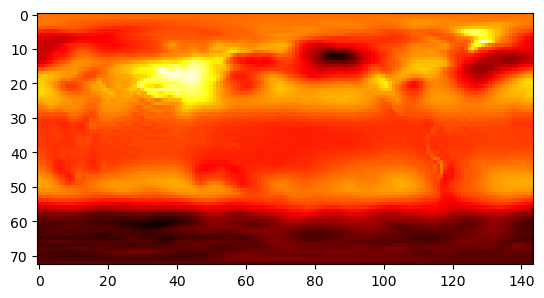

In [11]:
plt.imshow(slp[0].data, cmap='hot')
plt.show()

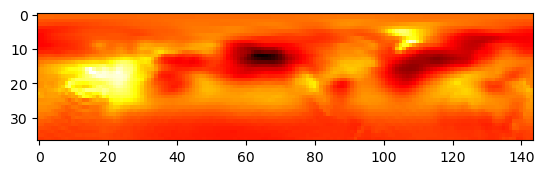

In [12]:
plt.imshow(np.hstack((slp_new[0][:, 21:], slp_new[0][:, 0:21])).data, cmap='hot')
plt.show()

## Flattening the HGT

In [13]:
slp_list = []
for i in range(len(slp_new)):
    slp_list.append(np.array(np.hstack((slp_new[i][:, 21:], slp_new[i][:, 0:21])).data.flatten()))

# Normalizing the data

In [14]:
start_year = 1948 

In [15]:
def del_29_Feb(reading_list,start_year):
    step = 0
    while start_year + step < 2024:
        if (start_year+step)%4 == 0:
            del reading_list[step*365+59]
        step += 1
    return reading_list[:step*365]

In [16]:
slp_list = del_29_Feb(slp_list,1948)

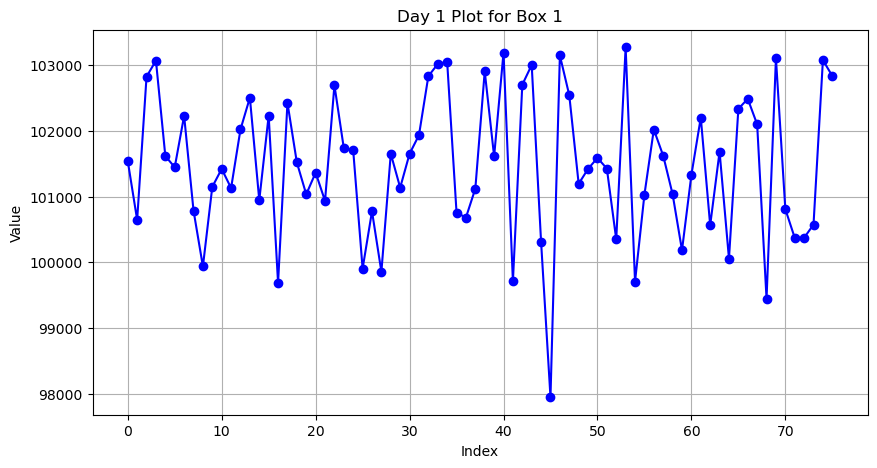

In [17]:
day_1 = []
for i in range(76):
    day_1.append(slp_list[i*365][0])
    
# Plotting the data
plt.figure(figsize=(10, 5))
plt.plot(day_1, marker='o', linestyle='-', color='b')

# Adding titles and labels
plt.title('Day 1 Plot for Box 1')
plt.xlabel('Index')
plt.ylabel('Value')

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [18]:
def av_day(reading_list):
    num_year = int(len(reading_list)/365)
    av_list = reading_list[:365]

    for i in range(1,num_year):
        for j in range(365):
            av_list[j] = av_list[j] + reading_list[i*365+j]
    
    for i in range(len(av_list)):
        av_list[i] = av_list[i]*1/num_year
    
    for i in range(num_year):
        for j in range(365):
            reading_list[i*365+j] = reading_list[i*365+j] - av_list[j]

    return reading_list

In [19]:
slp_list = av_day(slp_list)

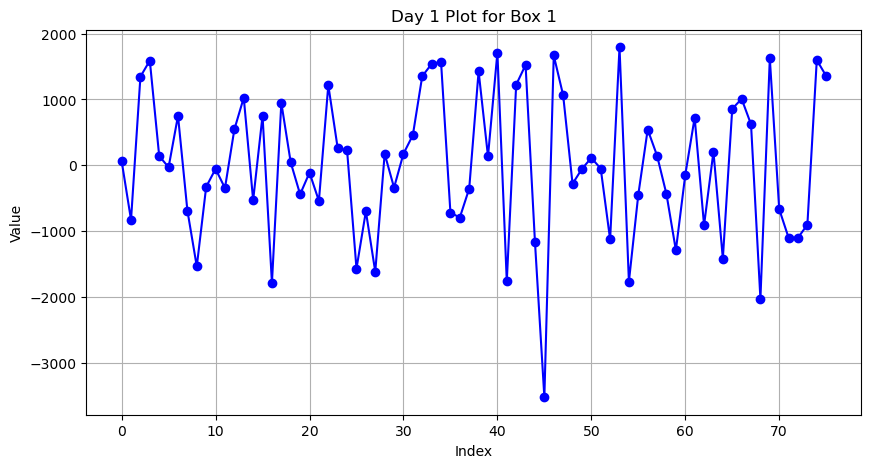

In [20]:
day_1 = []
for i in range(76):
    day_1.append(slp_list[i*365][0])
    
# Plotting the data
plt.figure(figsize=(10, 5))
plt.plot(day_1, marker='o', linestyle='-', color='b')

# Adding titles and labels
plt.title('Day 1 Plot for Box 1')
plt.xlabel('Index')
plt.ylabel('Value')

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [21]:
len(lon_index[:21]),len(lon_index[21:])

(21, 123)

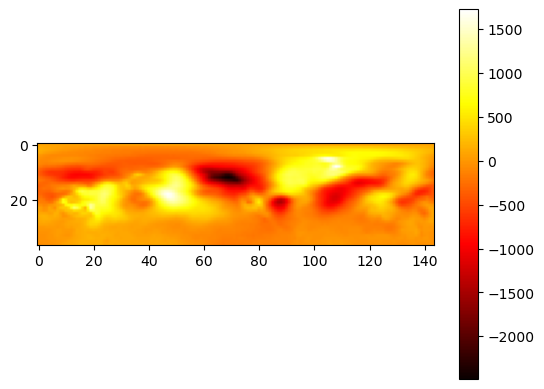

In [22]:
plt.imshow(slp_list[0].reshape((len(lat_index), len(lon_index))), cmap='hot')
plt.colorbar()
plt.show()

In [23]:
slp_2023 = slp_list[-365:]

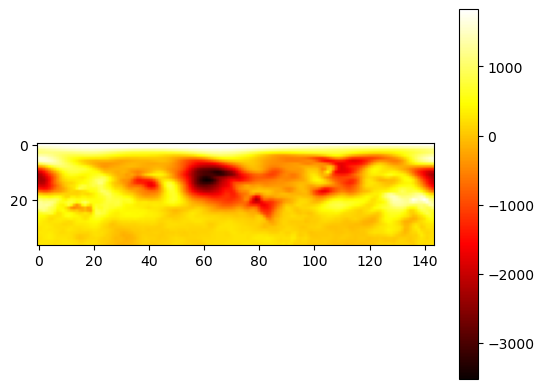

In [24]:
plt.imshow(slp_2023[1].reshape((len(lat_index), len(lon_index))), cmap='hot')
plt.colorbar()
plt.show()

## Plotting on Globe

In [25]:
lon_cut[0][0],lon_cut[0][1]

(0, 360)

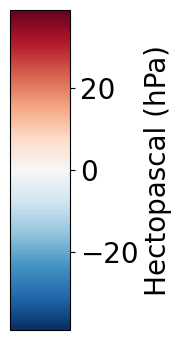

In [26]:
n=314
globe_visualization.create_standalone_colorbar(slp_2023[n]/100,lat_index, lon_index, tick_fontsize=20,label_fontsize=20)
#plt.savefig(notebook_directory+"/output/figures/visualization/global_projection_color_bar.png", dpi=500, bbox_inches='tight')  # PNG format
plt.show()

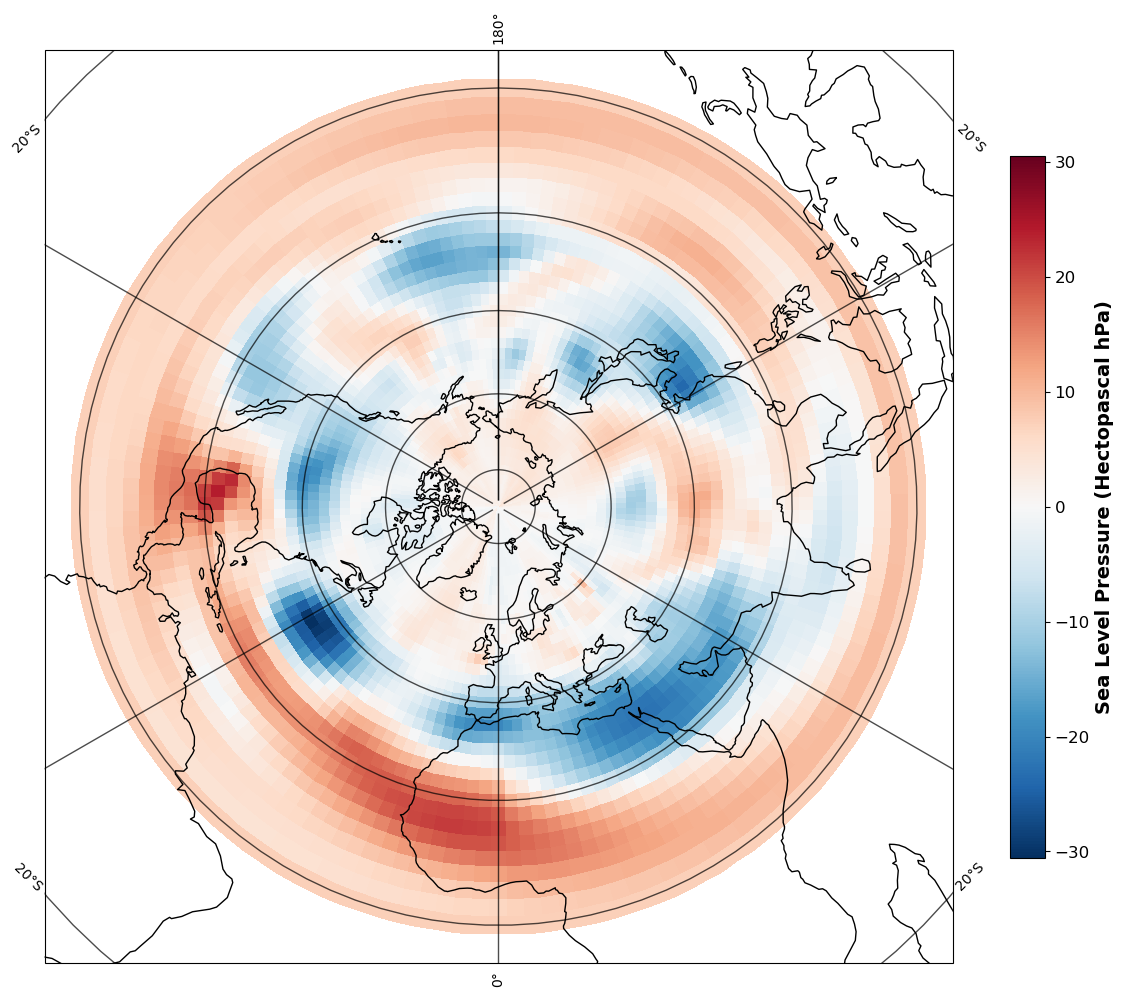

In [27]:
n=364
globe_visualization.plot_north_polar_stereo(slp_2023[n]/100, lat_index, lon_index)#/100 for Hectopascals
plt.savefig(notebook_directory+"/output/figures/visualization/global_projection.png", dpi=500, bbox_inches='tight')  # PNG format
plt.show()

# Cubical Persistence T-construction for Positive Region

### Data and PD

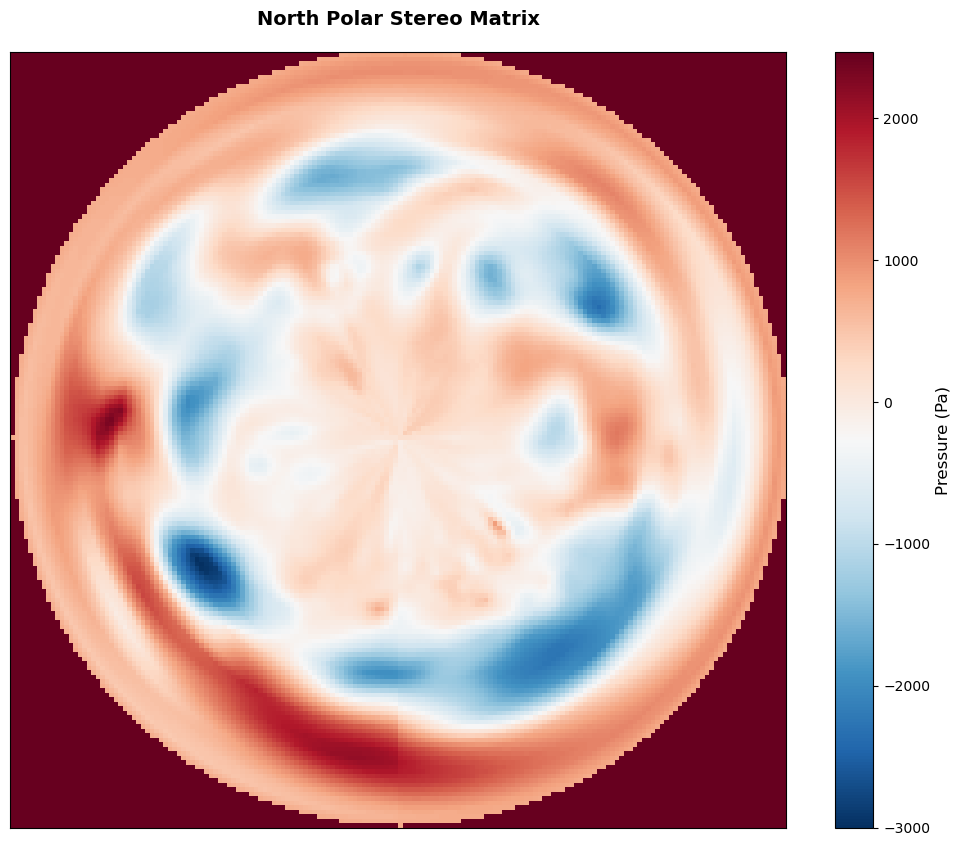

In [28]:
# Usage - matrix size calculated automatically:
polar_X = globe_visualization.reshape_to_polar_matrix(slp_2023[n], lat_index, lon_index, default_value="largest")

# Simple heatmap plot
fig, ax = globe_visualization.plot_simple_heatmap(polar_X, title="North Polar Stereo Matrix")
plt.show()

np.float64(15809.117567807436)

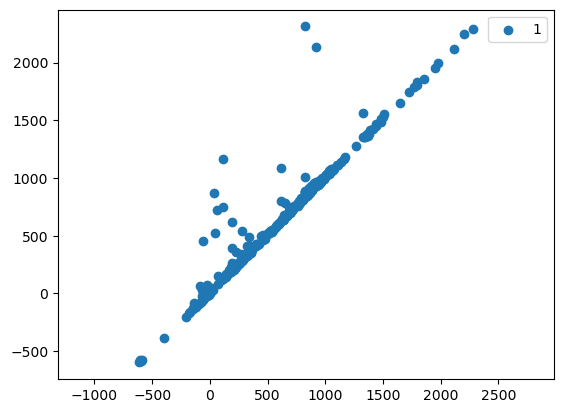

In [29]:
# Usage - matrix size calculated automatically:
polar_X = globe_visualization.reshape_to_polar_matrix(slp_2023[n], lat_index, lon_index, default_value="largest")
X = polar_X
P = tcr.computePH(X)
pdiag = cubical_pers_and_filt_visual.plot_cubical_ripser_diagram(P,dim_list=[1])
sum(pdiag[:,1]-pdiag[:,0])

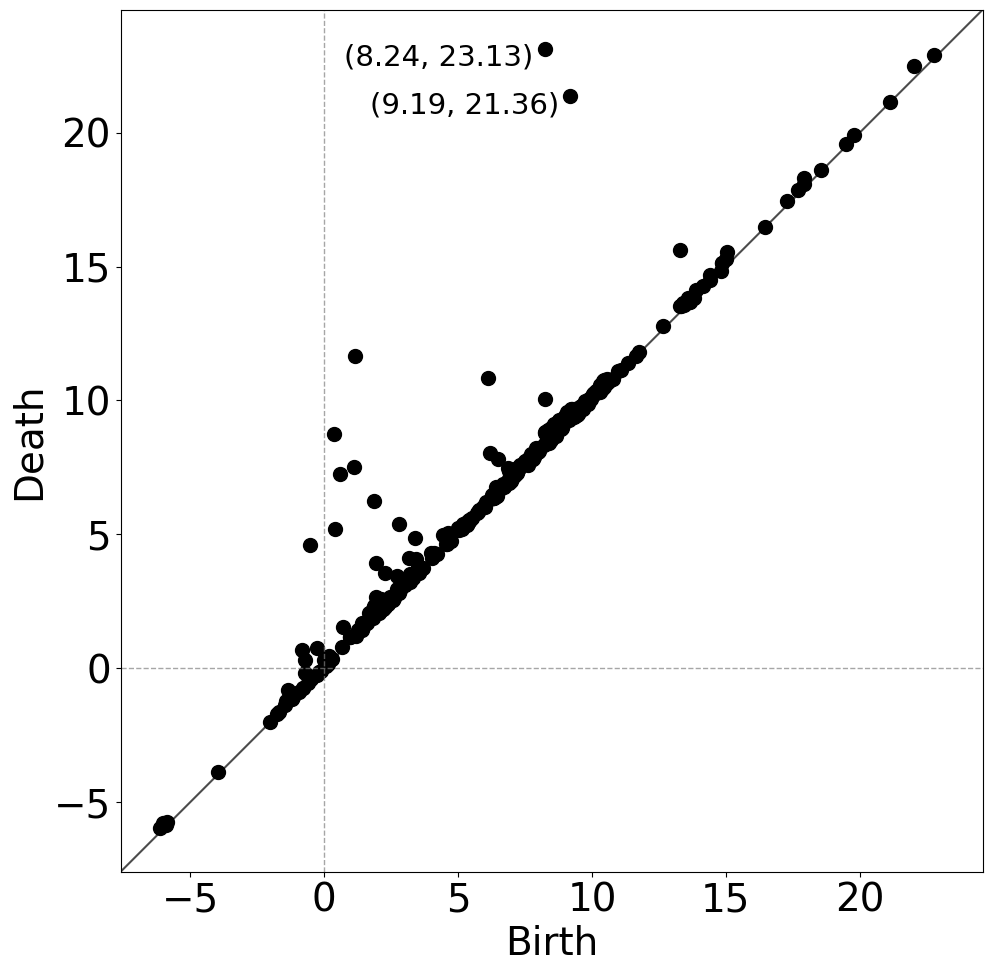

In [30]:
# Example usage:
cubical_pers_and_filt_visual.plot_points(pdiag/100, fontsize=28, annotate_top_n=2)#/100 for Hectopascals
plt.savefig(notebook_directory+"/output/figures/visualization/pd_cub_sub.png", dpi=500, bbox_inches='tight')  # PNG format
plt.show()

In [31]:
sum(pdiag[:,1]-pdiag[:,0])/100

np.float64(158.09117567807436)

In [32]:
pdiag = globe_visualization.sort_by_d_minus_b(pdiag)
pdiag[:2]

array([[ 823.71026611, 2312.70166016],
       [ 919.08654785, 2136.20776367]])

In [35]:
# compute sum of squared lifetimes normalized by 100
np.sum(((pdiag[:,1] - pdiag[:,0]) / 100.0) ** 2)

np.float64(779.5257047828104)

In [ ]:
# cubical_pers_and_filt_visual.vis(X/100)#/100 for Hectopascals

np.float64(23268.605414181948)

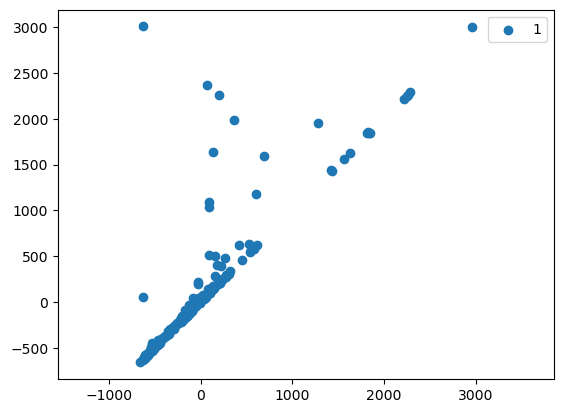

In [36]:
polar_X = globe_visualization.reshape_to_polar_matrix(slp_2023[n], lat_index, lon_index, default_value="smallest")
X = polar_X
P = tcr.computePH(-X)
pdiag = cubical_pers_and_filt_visual.plot_cubical_ripser_diagram(P,dim_list=[1])
sum(pdiag[:,1]-pdiag[:,0])

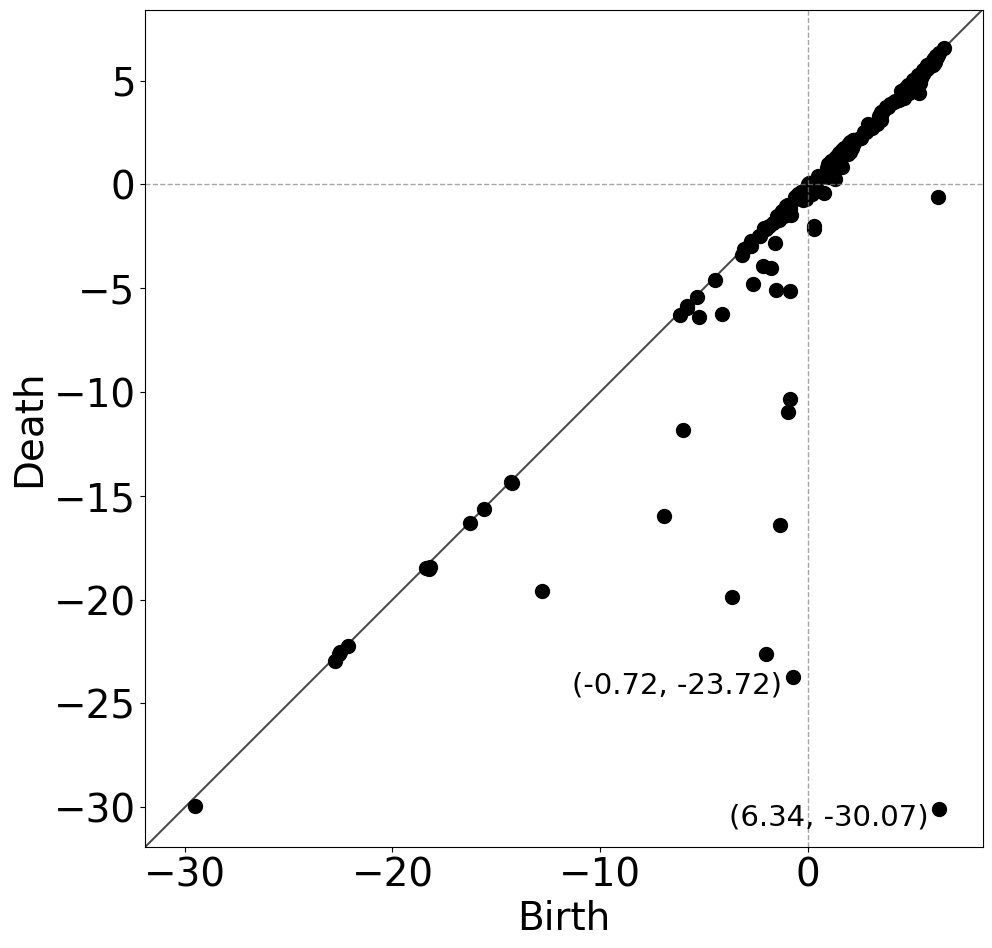

In [ ]:
# Example usage:
cubical_pers_and_filt_visual.plot_points(-pdiag/100, fontsize=28, annotate_top_n=2)#/100 for Hectopascals
plt.savefig(notebook_directory+"/output/figures/visualization/pd_cub_sup.png", dpi=500, bbox_inches='tight')  # PNG format
plt.show()

In [37]:
sum(pdiag[:,1]-pdiag[:,0])/100

np.float64(232.68605414181948)

In [38]:
# compute sum of squared lifetimes normalized by 100
np.sum(((pdiag[:,1] - pdiag[:,0]) / 100.0) ** 2)

np.float64(3249.2677155733936)

In [112]:
globe_visualization.sort_by_d_minus_b(pdiag)[:2]

array([[-633.83087158, 3006.75830078],
       [  72.3536377 , 2371.78515625]])

In [ ]:
cubical_pers_and_filt_visual.vis(-X/100)

interactive(children=(IntSlider(value=0, description='thr', max=31, min=-23), Output()), _dom_classes=('widget…

In [33]:
# # Example usage:
# cubical_pers_and_filt_visual.plot_points(pdiag, fontsize=28)
# plt.savefig(notebook_directory+"/output/figures/pd_cub_inc.png", dpi=500, bbox_inches='tight')  # PNG format
# plt.show()